# Extended Data Figure 5

Sam Gould, Kexin Dong

Cleaned: May 1, 2026

Last Updated: May 1, 2026

MBESv2 analytical pipeline and sensor construct characterization.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import scipy.stats
from sklearn.decomposition import PCA
from adjustText import adjust_text
from matplotlib_venn import venn2, venn3
from upsetplot import UpSet, from_indicators
import warnings
import os
warnings.filterwarnings('ignore')

# ── Global style (matching published figures) ─────────────────────────────────────────
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
plt.rcParams['font.family']     = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
yellows = sns.color_palette('Oranges').as_hex()
purples = sns.color_palette('Purples').as_hex()

greys = sns.color_palette('Greys').as_hex()
teals = sns.color_palette('BuPu').as_hex()
pinks = sns.color_palette('RdPu').as_hex()
browns = sns.color_palette('YlOrBr').as_hex()
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

## 5c Histogram of target base editing rate (top, dark blue) and pure correct editing rate (bottom, light blue) at the sensor locus for all samples of ABE screen.


In [ ]:
BASE = '/Users/kexindong/Documents/GitHub/B-ALL-in-vivo-base-editing/'

dfs = {
    'ABE_OG':         pd.read_csv(BASE + 'LFC-FDR/ABE_OG_LFC_FDR.csv', low_memory=False),
    'CBE_OG':         pd.read_csv(BASE + 'LFC-FDR/CBE_OG_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0':     pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_T0':     pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_BC':     pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'CBE_EPO_BC':     pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR.csv', low_memory=False),
    'ABE_BC_T0':      pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'CBE_BC_T0':      pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR.csv', low_memory=False),
    'ABE_EPO_T0_FSR': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_T0_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_EPO_T0_FSR': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_T0_LFC_FDR_FSR.csv', low_memory=False),
    'ABE_EPO_BC_FSR': pd.read_csv(BASE + 'LFC-FDR/ABE_FC_EPO_TO_BC_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_EPO_BC_FSR': pd.read_csv(BASE + 'LFC-FDR/CBE_FC_EPO_TO_BC_LFC_FDR_FSR.csv', low_memory=False),
    'ABE_BC_T0_FSR':  pd.read_csv(BASE + 'LFC-FDR/ABE_FC_BC_T0_LFC_FDR_FSR.csv', low_memory=False),
    'CBE_BC_T0_FSR':  pd.read_csv(BASE + 'LFC-FDR/CBE_FC_BC_T0_LFC_FDR_FSR.csv', low_memory=False),
}

# Conditions with FDR calculated
conds_og      = ['d15', 'bm', 'spleen', 'men']
conds_focused = ['d15', 'bm', 'spleen']

# Per-replicate raw count columns per condition per screen
rep_cols = {
    'ABE_OG':         {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4'],
                       'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_OG':         {'bm':    ['bonemarrow1','bonemarrow2','bonemarrow3','bonemarrow4','bonemarrow5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4'],
                       'men':   ['meninges1','meninges2','meninges3','meninges4','meninges5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_T0':     {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_T0':     {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                       'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_EPO_BC':     {'bm':    ['bm1','bm3','bm5'],
                       'spleen':['spleen1','spleen3'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_EPO_BC':     {'bm':    ['bm1','bm3','bm4','bm6','bm7','bm9','bm10'],
                       'spleen':['spleen1','spleen3','spleen4','spleen6','spleen7','spleen9','spleen10'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'ABE_BC_T0':      {'bm':    ['bm1','bm3','bm5'],
                       'spleen':['spleen1','spleen3'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    'CBE_BC_T0':      {'bm':    ['bm1','bm3','bm4','bm5','bm7','bm8','bm9'],
                       'spleen':['spleen1','spleen3','spleen4','spleen5','spleen7','spleen8','spleen9'],
                       'd15':   ['d15_rep1','d15_rep2','d15_rep3']},
    # FSR screens — d15 cols are 'd15-1','d15-2','d15-3'
    'ABE_EPO_T0_FSR': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_EPO_T0_FSR': {'bm':    ['bm1','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'ABE_EPO_BC_FSR': {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_EPO_BC_FSR': {'bm':    ['bm1','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'ABE_BC_T0_FSR':  {'bm':    ['bm1','bm2','bm3','bm4','bm5'],
                       'spleen':['spleen1','spleen2','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
    'CBE_BC_T0_FSR':  {'bm':    ['bm2','bm3','bm4','bm5'],
                       'spleen':['spleen2','spleen3','spleen4','spleen5'],
                       'd15':   ['d15-1','d15-2','d15-3']},
}

# COSMIC cancer gene census
cosmic = pd.read_csv(BASE + 'source-data/Census_allSun Nov 17 02_26_47 2024.csv').fillna('Undefined')
t_dict = {
    'TSG': 'TSG', 'TSG, fusion': 'TSG',
    'Undefined': 'Undefined', 'fusion': 'Undefined',
    'oncogene': 'Oncogene',
    'oncogene, TSG': 'Oncogene/TSG', 'oncogene, TSG, fusion': 'Oncogene/TSG',
    'oncogene, fusion': 'Oncogene',
}
color_dict = {'Oncogene':'tab:red', 'Oncogene/TSG':'tab:purple',
              'TSG':'tab:blue', 'Undefined':'tab:grey'}

def add_cosmic(df):
    gene_col = 'gene_name_h' if 'gene_name_h' in df.columns else 'Gene'
    roles = []
    for v in df[gene_col]:
        sub = cosmic[cosmic['Gene Symbol'] == v]
        roles.append('Undefined' if len(sub)==0 else t_dict.get(sub['Role in Cancer'].values[0], 'Undefined'))
    df = df.copy()
    df['Role in Cancer'] = roles
    df['color'] = [color_dict[r] for r in roles]
    return df

for key in dfs:
    dfs[key] = add_cosmic(dfs[key])

print('Loaded:')
for k, v in dfs.items():
    print(f'  {k}: {len(v)} guides')


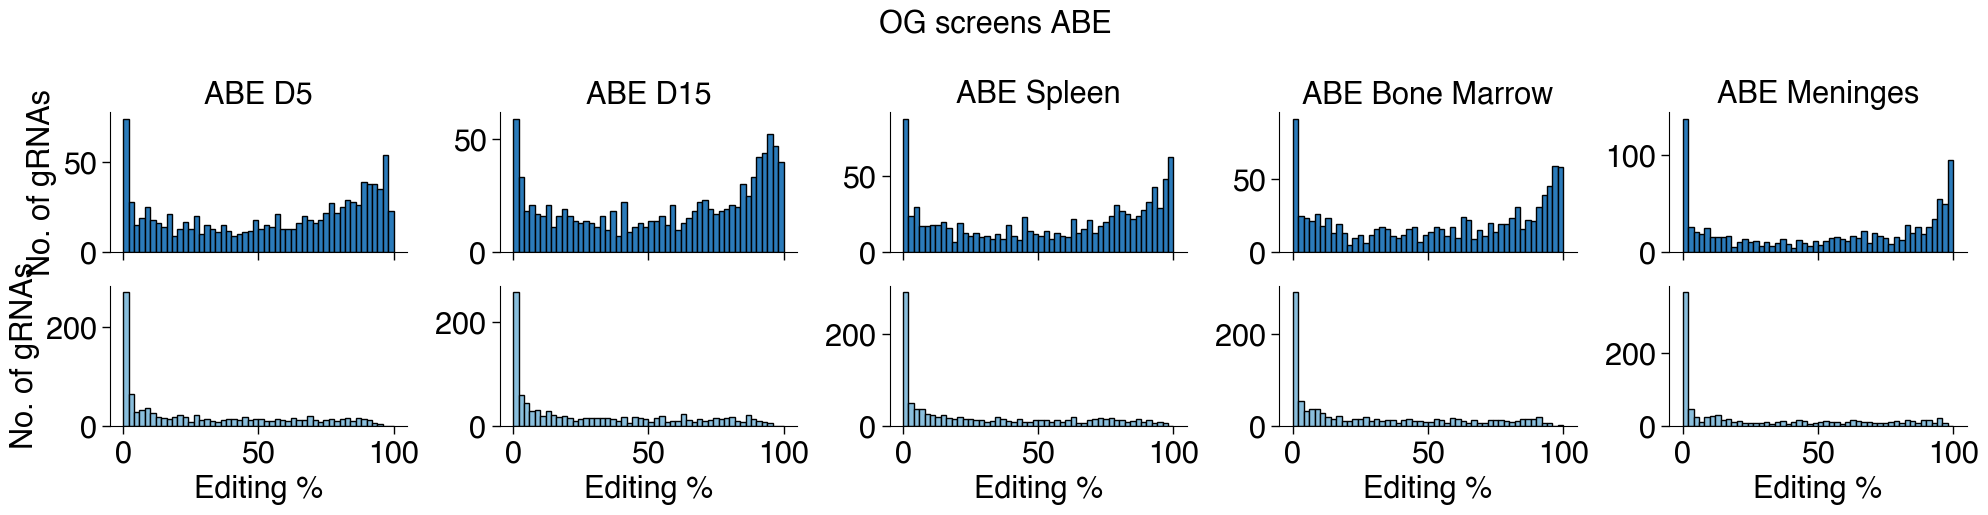

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


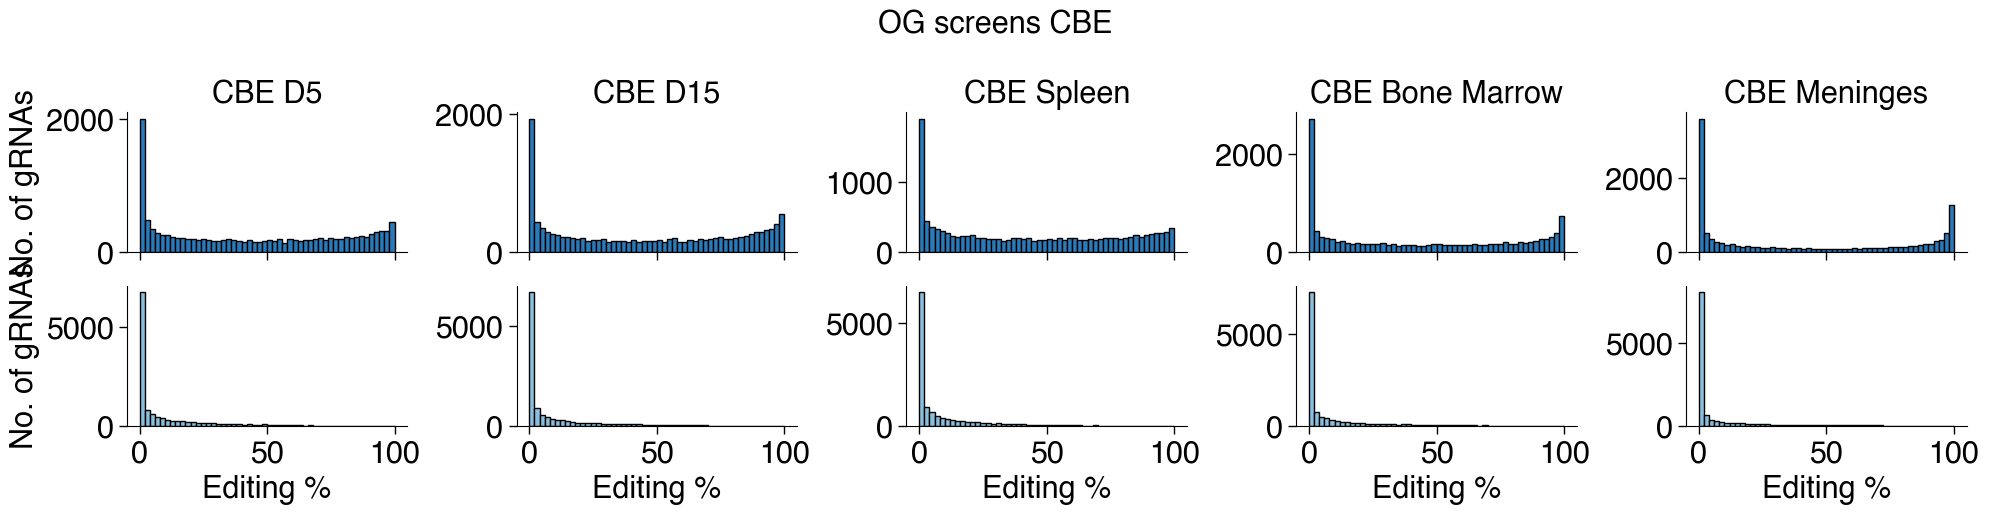

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
Zapf NOT subset; don't know how to subset; dropped
feat NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped


In [ ]:
# ── OG screens — editing efficiency histograms (all timepoints, figure 2f style) ──
BASE_mle = BASE + 'MLE/'

og_tps = ['d5', 'd15', 'spleen', 'bm', 'men']
og_tp_labels = {'d5': 'D5', 'd15': 'D15', 'spleen': 'Spleen', 'bm': 'Bone Marrow', 'men': 'Meninges'}
og_abe_files = {'d5': 'og/ABE/d5_ABE_MLE.csv', 'd15': 'og/ABE/d15_ABE_MLE.csv',
                'spleen': 'og/ABE/spleen_ABE_MLE.csv', 'bm': 'og/ABE/bm_ABE_MLE.csv',
                'men': 'og/ABE/men_ABE_MLE.csv'}
og_cbe_files = {'d5': 'og/CBE/d5_CBE_MLE.csv', 'd15': 'og/CBE/d15_CBE_MLE.csv',
                'spleen': 'og/CBE/spleen_CBE_MLE.csv', 'bm': 'og/CBE/bm_CBE_MLE.csv',
                'men': 'og/CBE/men_CBE_MLE.csv'}

ABE_og_guides = dfs['ABE_OG'][dfs['ABE_OG']['classification'] == 'targeting guide'][['gRNA_id']]
CBE_og_guides = dfs['CBE_OG'][dfs['CBE_OG']['classification'] == 'targeting guide'][['gRNA_id']]

n = len(og_tps)
fig, ax = plt.subplots(2, n, figsize=(4*n, 5), sharex=True, sharey=False)

for k, tp in enumerate(og_tps):
    abe = pd.read_csv(BASE_mle + og_abe_files[tp]).rename(columns={'Guide_ID': 'gRNA_id'})
    abe = pd.merge(abe, ABE_og_guides, on='gRNA_id')
    cbe = pd.read_csv(BASE_mle + og_cbe_files[tp]).rename(columns={'Guide_ID': 'gRNA_id'})
    cbe = pd.merge(cbe, CBE_og_guides, on='gRNA_id')
    ax[0][k].hist(abe['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=blues[4], edgecolor='black')
    ax[1][k].hist(abe['corr_perc'],             bins=np.linspace(0,100,51), linewidth=1, color=blues[2], edgecolor='black')
    ax[0][k].set_title(f'ABE {og_tp_labels[tp]}', fontsize=22)
    for row in [0, 1]:
        ax[row][k].spines[['top', 'right']].set_visible(False)
        ax[row][k].tick_params(axis='both', which='major', labelsize=22, direction='out', length=6, width=1)

ax[0][0].set_ylabel('No. of gRNAs', fontsize=22)
ax[1][0].set_ylabel('No. of gRNAs', fontsize=22)
for k in range(n):
    ax[1][k].set_xlabel('Editing %', fontsize=22)
fig.suptitle('OG screens ABE', fontsize=22, y=1.02)
fig.tight_layout()
plt.show()
fig.savefig('figures_final/fig_og_hist.pdf')

fig, ax = plt.subplots(2, n, figsize=(4*n, 5), sharex=True, sharey=False)

for k, tp in enumerate(og_tps):
    cbe = pd.read_csv(BASE_mle + og_cbe_files[tp]).rename(columns={'Guide_ID': 'gRNA_id'})
    cbe = pd.merge(cbe, CBE_og_guides, on='gRNA_id')
    ax[0][k].hist(cbe['target_base_edit_perc'], bins=np.linspace(0,100,51), linewidth=1, color=blues[4], edgecolor='black')
    ax[1][k].hist(cbe['corr_perc'],             bins=np.linspace(0,100,51), linewidth=1, color=blues[2], edgecolor='black')
    ax[0][k].set_title(f'CBE {og_tp_labels[tp]}', fontsize=22)
    for row in [0, 1]:
        ax[row][k].spines[['top', 'right']].set_visible(False)
        ax[row][k].tick_params(axis='both', which='major', labelsize=22, direction='out', length=6, width=1)

ax[0][0].set_ylabel('No. of gRNAs', fontsize=22)
ax[1][0].set_ylabel('No. of gRNAs', fontsize=22)
for k in range(n):
    ax[1][k].set_xlabel('Editing %', fontsize=22)
fig.suptitle('OG screens CBE', fontsize=22, y=1.02)
fig.tight_layout()
plt.show()
fig.savefig('figures_final/fig_og_cbe_hist.pdf')